<a href="https://colab.research.google.com/github/saniyaverma/DGFL-for-plant-disease-detection/blob/main/CL_Corn_Tomato.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# IMPORTS
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# ============================================================
# GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

CHECKPOINT_DIR = "/content/drive/MyDrive/Centralized_corn_tomato"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("Checkpoint directory:", CHECKPOINT_DIR)

Mounted at /content/drive
Checkpoint directory: /content/drive/MyDrive/Centralized_corn_tomato


In [ ]:
# ============================================================
# DEVICE + SEED
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [ ]:
# ============================================================
# DOWNLOAD DATASETS
# ============================================================

!pip install -q kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d ashishmotwani/tomato
!kaggle datasets download -d kaustubhb999/tomatoleaf
!kaggle datasets download -d luisolazo/tomato-diseases

!kaggle datasets download -d smaranjitghose/corn-or-maize-leaf-disease-dataset
!kaggle datasets download -d nafishamoin/new-bangladeshi-crop-disease
!kaggle datasets download -d karagwaanntreasure/plant-disease-detection

!unzip -q tomato.zip -d tomato_A
!unzip -q tomatoleaf.zip -d tomato_B
!unzip -q tomato-diseases.zip -d tomato_OOD

!unzip -q corn-or-maize-leaf-disease-dataset.zip -d corn_A
!unzip -q new-bangladeshi-crop-disease.zip -d corn_B
!unzip -q plant-disease-detection.zip -d corn_OOD

Dataset URL: https://www.kaggle.com/datasets/ashishmotwani/tomato
License(s): copyright-authors
 92% 1.26G/1.37G [00:14<00:02, 46.1MB/s]
100% 1.37G/1.37G [00:14<00:00, 99.5MB/s]
Dataset URL: https://www.kaggle.com/datasets/kaustubhb999/tomatoleaf
License(s): CC0-1.0
 85% 152M/179M [00:00<00:00, 1.59GB/s]
100% 179M/179M [00:00<00:00, 1.09GB/s]
Dataset URL: https://www.kaggle.com/datasets/luisolazo/tomato-diseases
License(s): CC0-1.0
 95% 390M/411M [00:00<00:00, 428MB/s]
100% 411M/411M [00:00<00:00, 476MB/s]
Dataset URL: https://www.kaggle.com/datasets/smaranjitghose/corn-or-maize-leaf-disease-dataset
License(s): copyright-authors
 96% 154M/161M [00:00<00:00, 1.61GB/s]
100% 161M/161M [00:00<00:00, 1.37GB/s]
Dataset URL: https://www.kaggle.com/datasets/nafishamoin/new-bangladeshi-crop-disease
License(s): copyright-authors
100% 2.34G/2.35G [00:37<00:00, 233MB/s]
100% 2.35G/2.35G [00:37<00:00, 66.5MB/s]
Dataset URL: https://www.kaggle.com/datasets/karagwaanntreasure/plant-disease-detection


In [ ]:
# ============================================================
# DATASET SCANNER
# ============================================================

def scan_dataset(root_dir, dataset_name, crop):

    records=[]

    for root, dirs, files in os.walk(root_dir):

        for f in files:

            if f.lower().endswith((".jpg",".png",".jpeg")):

                path=os.path.join(root,f)
                label=os.path.basename(root)

                records.append({
                    "dataset":dataset_name,
                    "crop":crop,
                    "path":path,
                    "raw_label":label
                })

    return pd.DataFrame(records)

In [ ]:
# ============================================================
# LOAD DATA
# ============================================================

df_tomato_A = scan_dataset("tomato_A","tomato_A","tomato")
df_tomato_B = scan_dataset("tomato_B/tomato","tomato_B","tomato")
df_tomato_OOD = scan_dataset("tomato_OOD","tomato_OOD","tomato")

df_corn_A = scan_dataset("corn_A","corn_A","corn")
df_corn_B = scan_dataset("corn_B","corn_B","corn")
df_corn_OOD = scan_dataset("corn_OOD","corn_OOD","corn")

df_all = pd.concat([
    df_tomato_A,
    df_tomato_B,
    df_corn_A,
    df_corn_B
]).reset_index(drop=True)

df_ood = pd.concat([
    df_tomato_OOD,
    df_corn_OOD
]).reset_index(drop=True)

print("Train pool:",len(df_all))
print("OOD pool:",len(df_ood))

Train pool: 62309
OOD pool: 57918


In [ ]:
# ============================================================
# LABEL SPACE
# ============================================================

labels = sorted(df_all.raw_label.unique())
label_to_id = {l:i for i,l in enumerate(labels)}

df_all["class_id"]=df_all.raw_label.map(label_to_id)
df_tomato_OOD["class_id"]=df_tomato_OOD.raw_label.map(label_to_id)
df_corn_OOD["class_id"]=df_corn_OOD.raw_label.map(label_to_id)

NUM_CLASSES=len(labels)

print("Total classes:",NUM_CLASSES)

Total classes: 40


In [ ]:
# ============================================================
# OOD DATASETS
# ============================================================

df_tomato_ood=df_tomato_OOD.copy()
df_corn_ood=df_corn_OOD.copy()

df_mixed_ood=pd.concat([
    df_tomato_ood,
    df_corn_ood
]).reset_index(drop=True)

In [ ]:
# ============================================================
# DOMAIN-WISE SPLIT
# ============================================================

def split_domain(df):

    train,temp=train_test_split(
        df,
        train_size=0.7,
        stratify=df.class_id,
        random_state=42
    )

    val,test=train_test_split(
        temp,
        train_size=0.5,
        stratify=temp.class_id,
        random_state=42
    )

    return train,val,test

df_tomato_A["class_id"]=df_tomato_A.raw_label.map(label_to_id)
df_tomato_B["class_id"]=df_tomato_B.raw_label.map(label_to_id)
df_corn_A["class_id"]=df_corn_A.raw_label.map(label_to_id)
df_corn_B["class_id"]=df_corn_B.raw_label.map(label_to_id)

train_tA,val_tA,test_tA=split_domain(df_tomato_A)
train_tB,val_tB,test_tB=split_domain(df_tomato_B)

train_cA,val_cA,test_cA=split_domain(df_corn_A)
train_cB,val_cB,test_cB=split_domain(df_corn_B)

train_df=pd.concat([train_tA,train_tB,train_cA,train_cB])
val_df=pd.concat([val_tA,val_tB,val_cA,val_cB])

In [ ]:
# ============================================================
# DATASET CLASS
# ============================================================

class CropDataset(Dataset):

    def __init__(self,df,transform=None):

        self.df=df.reset_index(drop=True)
        self.transform=transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self,idx):

        path=self.df.loc[idx,"path"]
        label=self.df.loc[idx,"class_id"]

        img=Image.open(path).convert("RGB")

        if self.transform:
            img=self.transform(img)

        return img,label

In [ ]:
# ============================================================
# TRANSFORMS
# ============================================================

train_transform=transforms.Compose([
transforms.Resize((256,256)),
transforms.RandomResizedCrop(224),
transforms.RandomHorizontalFlip(),
transforms.RandomVerticalFlip(),
transforms.RandomRotation(25),
transforms.ColorJitter(0.4,0.4,0.4,0.05),
transforms.GaussianBlur(3),
transforms.RandomGrayscale(p=0.1),
transforms.ToTensor(),
transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

test_transform=transforms.Compose([
transforms.Resize((224,224)),
transforms.ToTensor(),
transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [ ]:
# ============================================================
# DATALOADERS
# ============================================================

BATCH=32

train_loader=DataLoader(CropDataset(train_df,train_transform),batch_size=BATCH,shuffle=True)
val_loader=DataLoader(CropDataset(val_df,test_transform),batch_size=BATCH)

# IID loaders
tomato_test_A_loader=DataLoader(CropDataset(test_tA,test_transform),batch_size=BATCH)
tomato_test_B_loader=DataLoader(CropDataset(test_tB,test_transform),batch_size=BATCH)
corn_test_A_loader=DataLoader(CropDataset(test_cA,test_transform),batch_size=BATCH)
corn_test_B_loader=DataLoader(CropDataset(test_cB,test_transform),batch_size=BATCH)

# OOD loaders
unseen_tomato_loader=DataLoader(CropDataset(df_tomato_ood,test_transform),batch_size=BATCH)
unseen_corn_loader=DataLoader(CropDataset(df_corn_ood,test_transform),batch_size=BATCH)
combined_unseen_loader = DataLoader(CropDataset(df_mixed_ood,test_transform),batch_size=BATCH)

In [ ]:
# ============================================================
# MODEL
# ============================================================

model=resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc=nn.Linear(model.fc.in_features,NUM_CLASSES)
model=model.to(device)

criterion=nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer=optim.Adam(model.parameters(),lr=3e-5)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 113MB/s]


In [ ]:
# ============================================================
# CHECKPOINT LOADER
# ============================================================

def load_latest_checkpoint():

    files = [f for f in os.listdir(CHECKPOINT_DIR) if "latest_epoch" in f]

    if len(files) == 0:
        return None, 0

    files.sort()

    latest = files[-1]

    path = os.path.join(CHECKPOINT_DIR, latest)

    checkpoint = torch.load(path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    start_epoch = checkpoint["epoch"] + 1

    print("Loaded checkpoint:", latest)

    return checkpoint, start_epoch

In [ ]:
checkpoint, start_epoch = load_latest_checkpoint()

if checkpoint is None:

    print("Starting training from scratch")

    best_val = 0
    best_model = copy.deepcopy(model.state_dict())

else:

    print(f"Resuming from epoch {start_epoch}")

    best_val = checkpoint["best_val"]
    best_model = checkpoint["best_model"]

Loaded checkpoint: latest_epoch_1.pth
Resuming from epoch 1


In [16]:
# ============================================================
# TRAINING LOOP WITH CHECKPOINTS
# ============================================================

from tqdm import tqdm

EPOCHS = 10

for epoch in range(start_epoch, EPOCHS):

    model.train()
    running_loss = 0

    for images,labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs,labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    model.eval()

    correct,total = 0,0

    with torch.no_grad():

        for images,labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            preds = torch.argmax(outputs,1)

            total += labels.size(0)
            correct += (preds==labels).sum().item()

    val_acc = 100 * correct / total

    print(f"Epoch {epoch+1} | Loss {running_loss:.4f} | Val {val_acc:.2f}")

    # ======================
    # BEST MODEL
    # ======================

    if val_acc > best_val:

        best_val = val_acc
        best_model = copy.deepcopy(model.state_dict())

        torch.save({
            "epoch": epoch,
            "best_val": best_val,
            "model_state_dict": best_model
        }, os.path.join(CHECKPOINT_DIR,"best_model.pth"))

        print("Best model saved")

    # ======================
    # SAVE CHECKPOINT
    # ======================

    checkpoint_path = os.path.join(
        CHECKPOINT_DIR,
        f"latest_epoch_{epoch+1}.pth"
    )

    torch.save({
        "epoch": epoch,
        "best_val": best_val,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_model": best_model
    }, checkpoint_path)

    print("Checkpoint saved:", checkpoint_path)

100%|██████████| 1363/1363 [13:36<00:00,  1.67it/s]


Epoch 2 | Loss 1998.1227 | Val 66.56
Best model saved
Checkpoint saved: /content/drive/MyDrive/Centralized_corn_tomato/latest_epoch_2.pth


100%|██████████| 1363/1363 [13:07<00:00,  1.73it/s]


Epoch 3 | Loss 2069.0146 | Val 68.57
Best model saved
Checkpoint saved: /content/drive/MyDrive/Centralized_corn_tomato/latest_epoch_3.pth


100%|██████████| 1363/1363 [13:10<00:00,  1.72it/s]


...

Epoch 8 | Loss 1866.3758 | Val 70.76
Checkpoint saved: /content/drive/MyDrive/Centralized_corn_tomato/latest_epoch_8.pth


100%|██████████| 1363/1363 [14:05<00:00,  1.61it/s]


Epoch 9 | Loss 1849.8510 | Val 71.83
Best model saved
Checkpoint saved: /content/drive/MyDrive/Centralized_corn_tomato/latest_epoch_9.pth


100%|██████████| 1363/1363 [13:42<00:00,  1.66it/s]


Epoch 10 | Loss 1835.6059 | Val 71.11
Checkpoint saved: /content/drive/MyDrive/Centralized_corn_tomato/latest_epoch_10.pth


In [21]:
# ============================================================
# EVALUATION FUNCTIONS
# ============================================================
from sklearn.metrics import balanced_accuracy_score

best_checkpoint = torch.load(
    os.path.join(CHECKPOINT_DIR,"best_model.pth"),
    map_location=device
)

model.load_state_dict(best_checkpoint["model_state_dict"])
model.eval()

def evaluate(loader):

    preds=[]
    labels=[]

    with torch.no_grad():

        for images,l in loader:

            images=images.to(device)

            outputs=model(images)

            p=torch.argmax(outputs,1).cpu().numpy()

            preds.extend(p)
            labels.extend(l.numpy())

    return np.array(labels),np.array(preds)


def evaluate_domain(loader,name):

    y_true,y_pred=evaluate(loader)

    # Get unique labels present in the current data
    unique_labels = np.unique(y_true)

    # Create a reverse mapping from id to label name for easy lookup
    id_to_label = {v: k for k, v in label_to_id.items()}
    # Filter target_names to match the unique labels
    filtered_target_names = [id_to_label[label_id] for label_id in unique_labels]


    print("\n==============================")
    print(name)
    print("==============================")

    print(classification_report(
        y_true,
        y_pred,
        labels=unique_labels, # Explicitly pass the labels present in the data
        target_names=filtered_target_names
    ))

    cm=confusion_matrix(y_true,y_pred, labels=unique_labels) # Pass labels to confusion matrix as well
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    plt.figure(figsize=(8,7))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=filtered_target_names, # Use filtered target names
        yticklabels=filtered_target_names  # Use filtered target names
    )

    plt.title(name+" Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.show()
    print("Balanced Accuracy:",round(bal_acc*100, 2), "%")


IID TEST - Tomato A
                                      precision    recall  f1-score   support

                      Bacterial_spot       0.98      0.87      0.92       534
                        Early_blight       0.97      0.94      0.96       465
                         Late_blight       0.93      0.96      0.95       586
                           Leaf_Mold       0.97      0.96      0.97       524
                  Septoria_leaf_spot       0.91      0.94      0.93       545
Spider_mites Two-spotted_spider_mite       0.98      1.00      0.99       327
                         Target_Spot       0.98      0.96      0.97       342
       Tomato_Yellow_Leaf_Curl_Virus       0.99      0.97      0.98       380
                 Tomato_mosaic_virus       0.95      0.94      0.95       411
                             healthy       0.98      0.99      0.99       579
                      powdery_mildew       0.95      0.91      0.93       188

                           micro avg     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


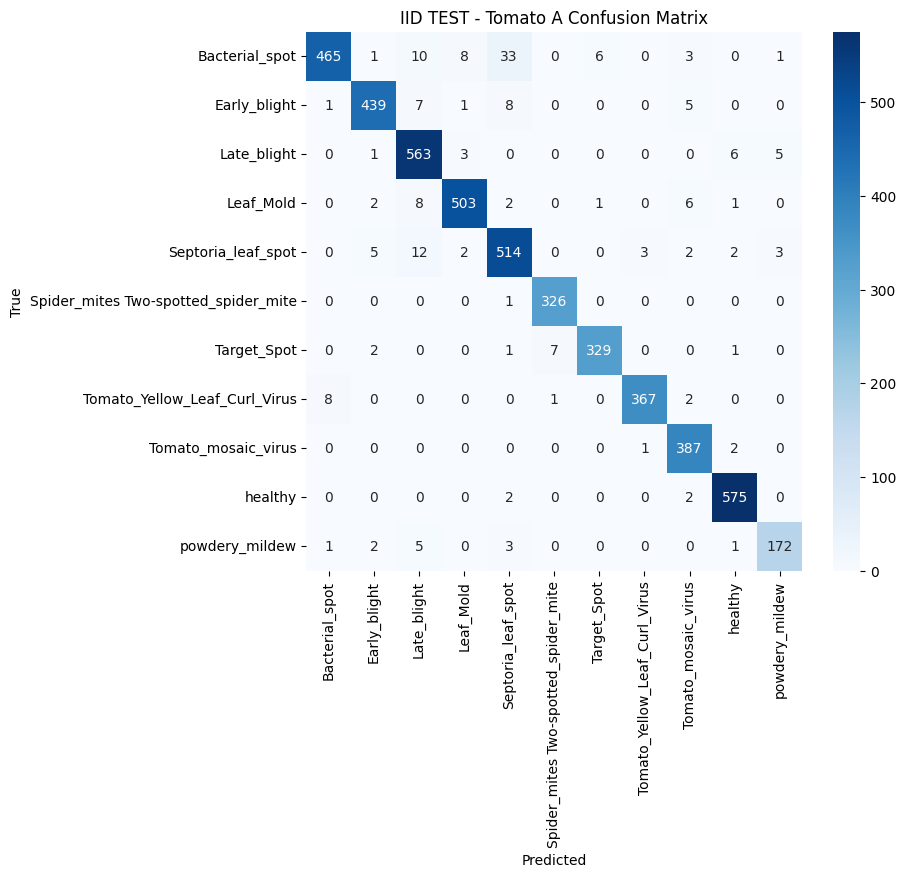

Balanced Accuracy: 95.03 %

IID TEST - Tomato B
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       1.00      0.01      0.02       165
                        Tomato___Early_blight       0.00      0.00      0.00       165
                         Tomato___Late_blight       1.00      0.01      0.01       165
                           Tomato___Leaf_Mold       0.00      0.00      0.00       165
                  Tomato___Septoria_leaf_spot       0.00      0.00      0.00       165
Tomato___Spider_mites Two-spotted_spider_mite       0.00      0.00      0.00       165
                         Tomato___Target_Spot       0.00      0.00      0.00       166
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.00      0.00      0.00       165
                 Tomato___Tomato_mosaic_virus       1.00      0.07      0.14       165
                             Tomato___healthy       0.00      0.00      0.00     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

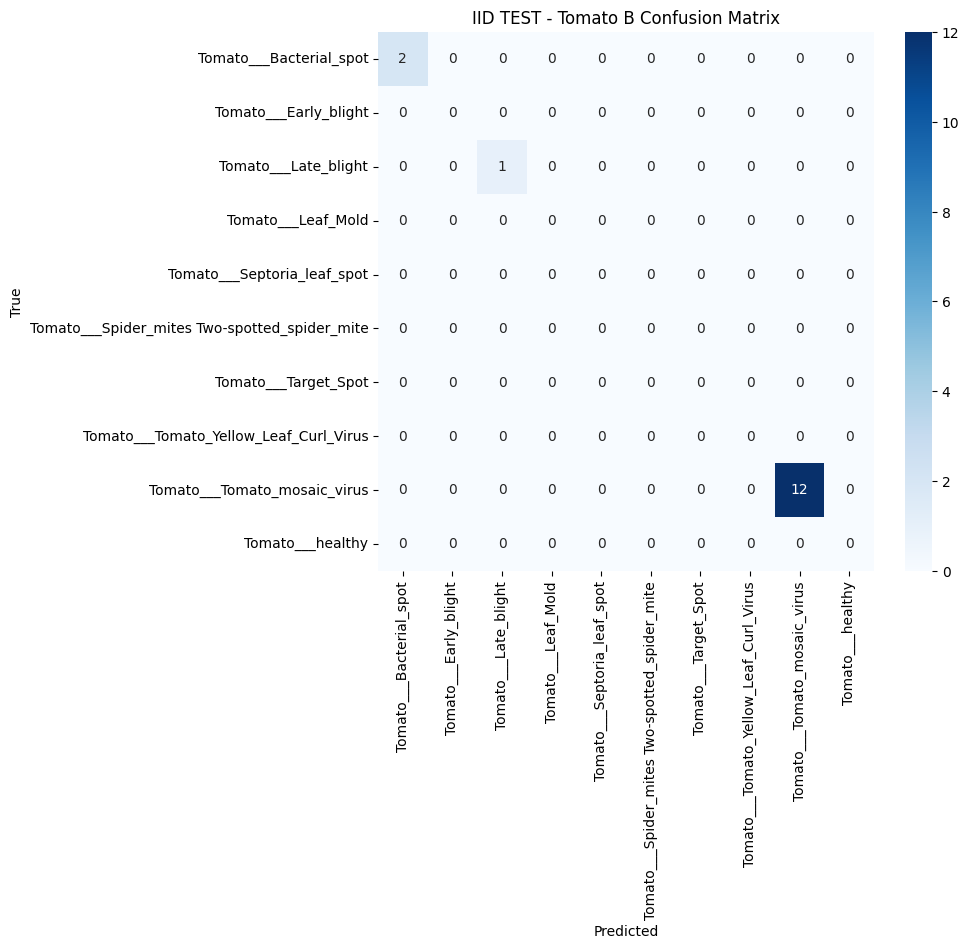

Balanced Accuracy: 0.91 %

IID TEST - Corn A
                precision    recall  f1-score   support

        Blight       0.91      0.35      0.50       172
   Common_Rust       1.00      0.70      0.83       196
Gray_Leaf_Spot       0.85      0.47      0.60        86
       Healthy       1.00      0.54      0.70       175

     micro avg       0.96      0.53      0.68       629
     macro avg       0.94      0.51      0.66       629
  weighted avg       0.95      0.53      0.67       629



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


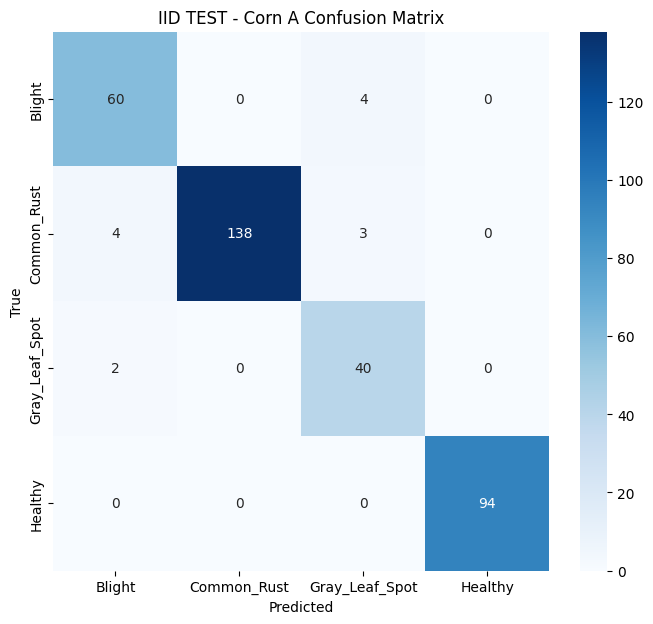

Balanced Accuracy: 51.38 %

IID TEST - Corn B
                             precision    recall  f1-score   support

         Corn___Common_Rust       1.00      0.21      0.35       179
      Corn___Gray_Leaf_Spot       0.97      0.40      0.57        77
             Corn___Healthy       1.00      0.27      0.43       175
Corn___Northern_Leaf_Blight       0.93      0.67      0.78       148
                    Invalid       1.00      1.00      1.00       235
      Potato___Early_Blight       1.00      1.00      1.00       150
           Potato___Healthy       0.96      0.96      0.96        23
       Potato___Late_Blight       0.99      0.99      0.99       150
          Rice___Brown_Spot       0.73      0.65      0.69        92
             Rice___Healthy       0.83      0.95      0.89       223
          Rice___Leaf_Blast       0.83      0.72      0.77       146
          Rice___Neck_Blast       1.00      1.00      1.00       150
         Wheat___Brown_Rust       0.99      0.99      0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


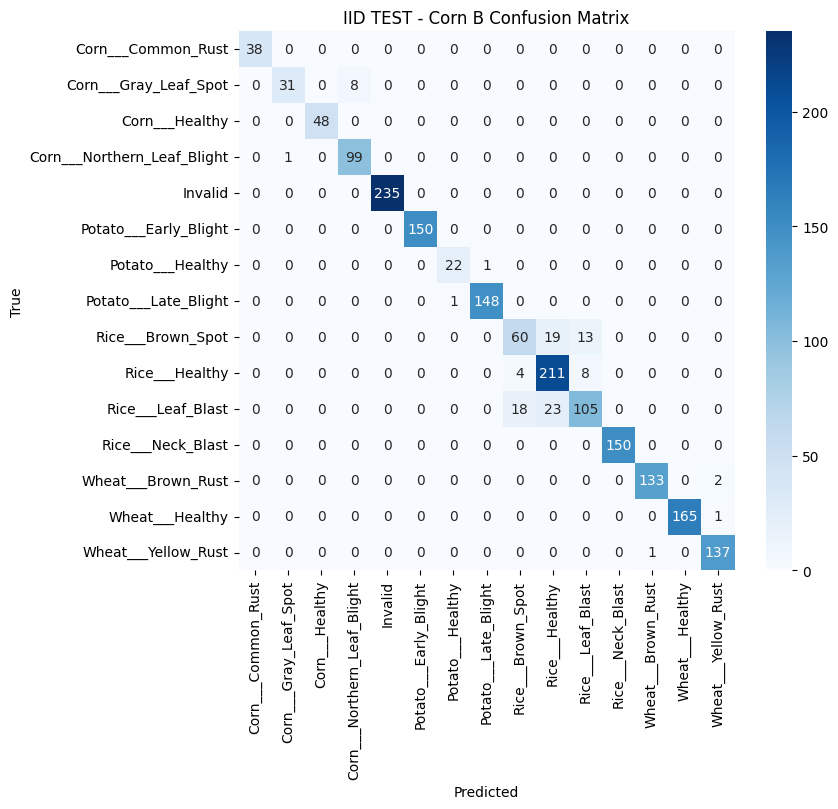

Balanced Accuracy: 78.53 %


In [22]:
# ============================================================
# IID TESTS
# ============================================================

evaluate_domain(tomato_test_A_loader,"IID TEST - Tomato A")
evaluate_domain(tomato_test_B_loader,"IID TEST - Tomato B")
evaluate_domain(corn_test_A_loader,"IID TEST - Corn A")
evaluate_domain(corn_test_B_loader,"IID TEST - Corn B")

In [23]:
# ============================================================
# OOD TESTS
# ============================================================

evaluate_domain(unseen_tomato_loader,"OOD TEST - Unseen Tomato")
evaluate_domain(unseen_corn_loader,"OOD TEST - Unseen Corn")
evaluate_domain(combined_unseen_loader,"OOD TEST - Combined Tomato + Corn")

KeyError: np.float64(nan)